# Arquitetura LeNet-5 (ReLU)

Implementação da arquitetura LeNet-5 utilizando PyTorch com ativação ReLU.

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        # Camada C1: Convolucional
        # Entrada: 1 canal (Grayscale), Saída: 6 canais, Filtro: 5x5
        # Padding=2 para ajustar imagens 28x28 para o comportamento de 32x32 da arquitetura original
        self.c1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2)
        
        # Camada S2: Pooling (Subsampling)
        self.s2 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # Camada C3: Convolucional
        # Entrada: 6 canais, Saída: 16 canais, Filtro: 5x5
        self.c3 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1)
        
        # Camada S4: Pooling (Subsampling)
        self.s4 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # Camada C5: Convolucional (ou Fully Connected)
        # Aqui implementada como Linear após o flatten
        self.c5 = nn.Linear(in_features=16 * 5 * 5, out_features=120)
        
        # Camada F6: Fully Connected
        self.f6 = nn.Linear(in_features=120, out_features=84)
        
        # Camada de Saída
        self.output = nn.Linear(in_features=84, out_features=num_classes)

    def forward(self, x):
        # C1 -> ReLU -> S2
        x = F.relu(self.c1(x))
        x = self.s2(x)
        
        # C3 -> ReLU -> S4
        x = F.relu(self.c3(x))
        x = self.s4(x)
        
        # Flatten
        x = torch.flatten(x, 1)
        
        # C5 -> ReLU
        x = F.relu(self.c5(x))
        
        # F6 -> ReLU
        x = F.relu(self.f6(x))
        
        # Output
        x = self.output(x)
        
        return x

## Carregamento do Dataset MNIST
Vamos baixar o dataset MNIST e preparar um DataLoader para visualizar alguns exemplos.

In [11]:
# Transformação: Converter para Tensor e Normalizar
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download dos dados de treino e teste
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"Dataset de treino: {len(train_dataset)} imagens")
print(f"Dataset de teste: {len(test_dataset)} imagens")

Dataset de treino: 60000 imagens
Dataset de teste: 10000 imagens


## Treinamento do Modelo
Definição da função de perda (Loss), otimizador e o loop de treinamento.

Iniciando treinamento no dispositivo: cpu
Epoch 1 [100/938] Loss: 1.0138
Epoch 1 [200/938] Loss: 0.3467
Epoch 1 [300/938] Loss: 0.2514
Epoch 1 [400/938] Loss: 0.2102
Epoch 1 [500/938] Loss: 0.1573
Epoch 1 [600/938] Loss: 0.1395
Epoch 1 [700/938] Loss: 0.1432
Epoch 1 [800/938] Loss: 0.1029
Epoch 1 [900/938] Loss: 0.1100
Epoch 2 [100/938] Loss: 0.0917
Epoch 2 [200/938] Loss: 0.0843
Epoch 2 [300/938] Loss: 0.0830
Epoch 2 [400/938] Loss: 0.0752
Epoch 2 [500/938] Loss: 0.0671
Epoch 2 [600/938] Loss: 0.0693
Epoch 2 [700/938] Loss: 0.0887
Epoch 2 [800/938] Loss: 0.0695
Epoch 2 [900/938] Loss: 0.0769
Epoch 3 [100/938] Loss: 0.0567
Epoch 3 [200/938] Loss: 0.0593
Epoch 3 [300/938] Loss: 0.0523
Epoch 3 [400/938] Loss: 0.0558
Epoch 3 [500/938] Loss: 0.0634
Epoch 3 [600/938] Loss: 0.0563
Epoch 3 [700/938] Loss: 0.0508
Epoch 3 [800/938] Loss: 0.0566
Epoch 3 [900/938] Loss: 0.0550
Epoch 4 [100/938] Loss: 0.0425
Epoch 4 [200/938] Loss: 0.0489
Epoch 4 [300/938] Loss: 0.0474
Epoch 4 [400/938] Loss: 0.04

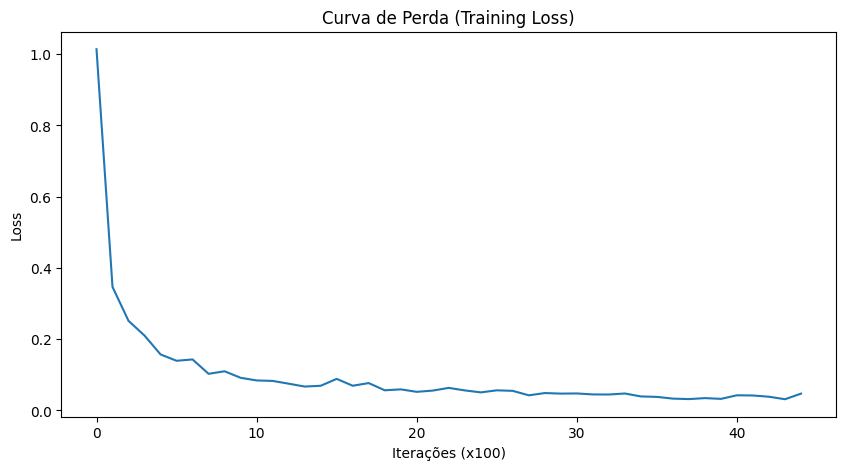

In [12]:
# Configurações
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LeNet5().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

epochs = 5
train_losses = []

print(f"Iniciando treinamento no dispositivo: {device}")

model.train()
for epoch in range(epochs):
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        # Zerar gradientes
        optimizer.zero_grad()
        
        # Forward pass
        output = model(data)
        
        # Calcular perda
        loss = criterion(output, target)
        
        # Backward pass e otimização
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if batch_idx % 100 == 99:
            avg_loss = running_loss / 100
            print(f'Epoch {epoch+1} [{batch_idx+1}/{len(train_loader)}] Loss: {avg_loss:.4f}')
            train_losses.append(avg_loss)
            running_loss = 0.0

print("Treinamento finalizado!")

# Plotar curva de aprendizado
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title("Curva de Perda (Training Loss)")
plt.xlabel("Iterações (x100)")
plt.ylabel("Loss")
plt.show()

## Visualização dos Filtros (Pesos Pós-Treinamento)
Comparação dos filtros após o modelo ter aprendido as características do MNIST.

Visualizando filtros da camada C1 após o treinamento:


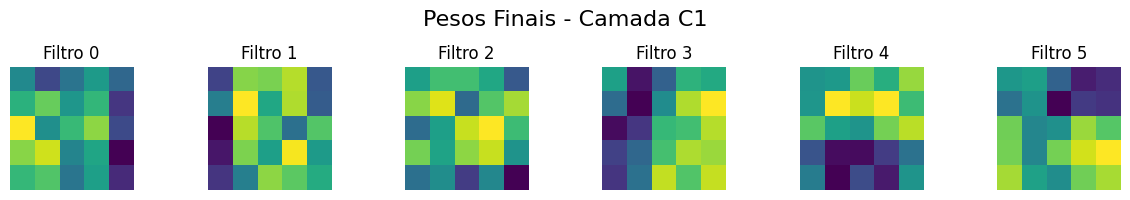

In [13]:
def plot_filters(layer_weights, title):
    filters = layer_weights.detach().cpu().numpy()
    n_filters = filters.shape[0]
    
    fig, axes = plt.subplots(1, n_filters, figsize=(n_filters * 2, 2))
    fig.suptitle(title, fontsize=16)
    
    for i in range(n_filters):
        ax = axes[i]
        ax.imshow(filters[i, 0], cmap='viridis')
        ax.axis('off')
        ax.set_title(f'Filtro {i}')
    plt.tight_layout()
    plt.show()

print("Visualizando filtros da camada C1 após o treinamento:")
plot_filters(model.c1.weight, "Pesos Finais - Camada C1")

## Avaliação de Performance
Agora vamos avaliar a precisão (accuracy) do modelo no dataset de teste e visualizar algumas predições.

Acurácia no dataset de teste: 98.85%


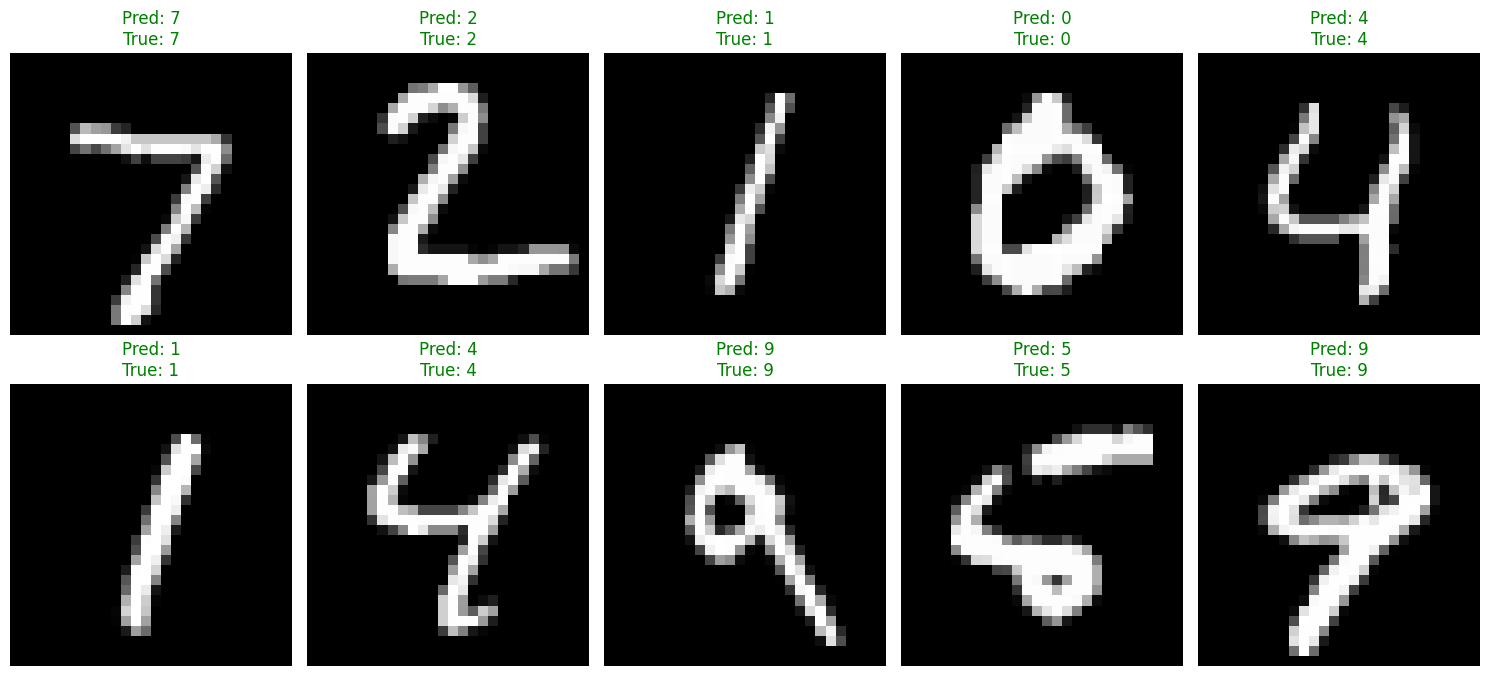

In [14]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

accuracy = 100 * correct / total
print(f'Acurácia no dataset de teste: {accuracy:.2f}%')

# Visualizar predições em um pequeno batch
data_iter = iter(test_loader)
images, labels = next(data_iter)
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for i in range(10):
    ax = axes[i//5, i%5]
    ax.imshow(images[i].cpu().numpy().squeeze(), cmap='gray')
    color = 'green' if predicted[i] == labels[i] else 'red'
    ax.set_title(f"Pred: {predicted[i].item()}\nTrue: {labels[i].item()}", color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Análise de Erros
Vamos identificar quais imagens o modelo está classificando incorretamente para entender onde ele falha.

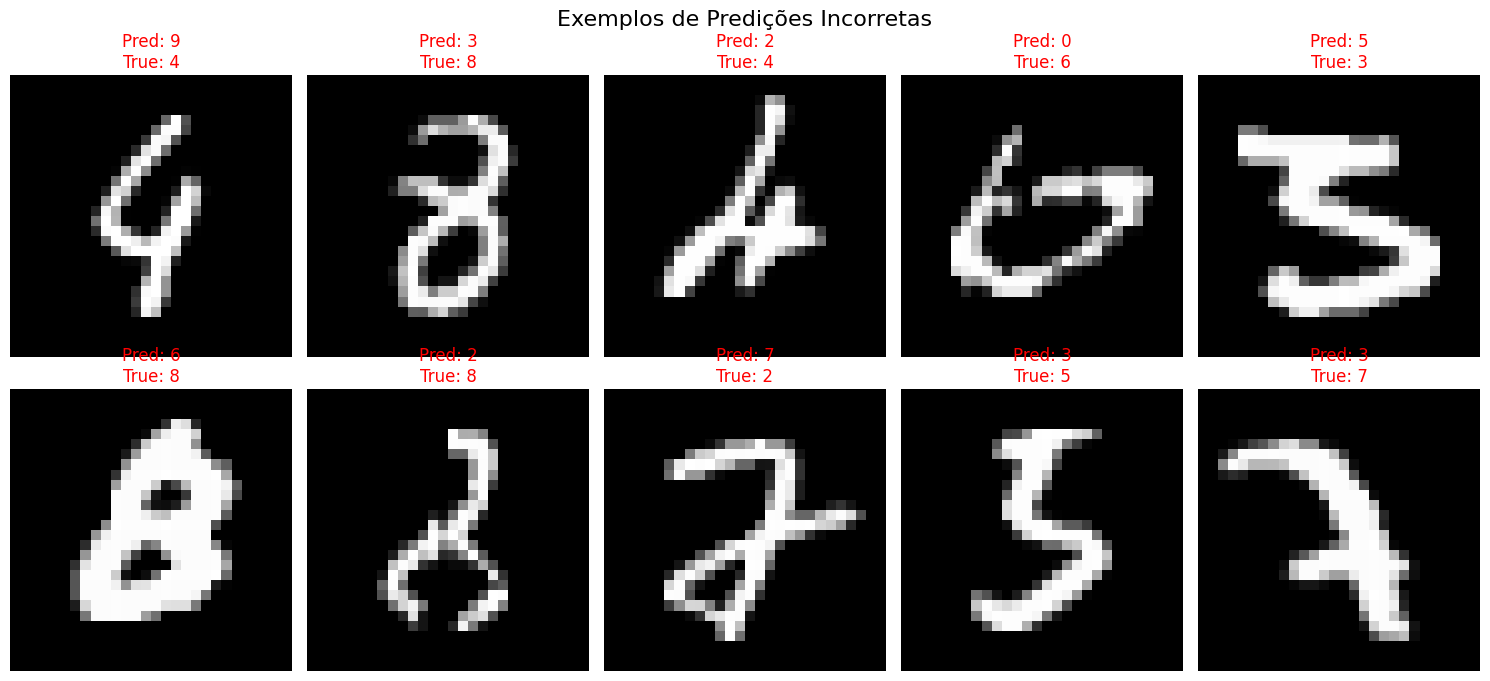

In [15]:
model.eval()
misclassified_images = []
misclassified_preds = []
misclassified_labels = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs, 1)
        
        # Encontrar índices onde a predição é diferente do label real
        idxs = (predicted != target).nonzero(as_tuple=True)[0]
        
        for idx in idxs:
            if len(misclassified_images) < 10: # Limitar para visualização
                misclassified_images.append(data[idx].cpu())
                misclassified_preds.append(predicted[idx].cpu())
                misclassified_labels.append(target[idx].cpu())

# Visualizar os erros encontrados
if misclassified_images:
    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    fig.suptitle("Exemplos de Predições Incorretas", fontsize=16)
    for i in range(len(misclassified_images)):
        ax = axes[i//5, i%5]
        ax.imshow(misclassified_images[i].squeeze(), cmap='gray')
        ax.set_title(f"Pred: {misclassified_preds[i].item()}\nTrue: {misclassified_labels[i].item()}", color='red')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum erro encontrado no dataset de teste!")

## Salvamento do Modelo
Finalmente, vamos salvar os pesos do modelo treinado para uso futuro.

In [16]:
# Caminho para salvar o modelo
torch.save(model.state_dict(), 'lenet5_mnist.pth')
print("Modelo salvo com sucesso como 'lenet5_mnist.pth'!")

Modelo salvo com sucesso como 'lenet5_mnist.pth'!


## Carregamento do Modelo
Podemos carregar os pesos salvos em uma nova instância da rede para realizar inferências sem precisar treinar novamente.

In [17]:
# Criar uma nova instância do modelo
loaded_model = LeNet5().to(device)

# Carregar os pesos salvos
loaded_model.load_state_dict(torch.load('lenet5_mnist.pth'))
loaded_model.eval()

print("Modelo carregado com sucesso a partir de 'lenet5_mnist.pth'!")

Modelo carregado com sucesso a partir de 'lenet5_mnist.pth'!


## Visualização dos Mapas de Características (Feature Maps)
Vamos visualizar o resultado da primeira camada (C1) aplicada a uma imagem de entrada.

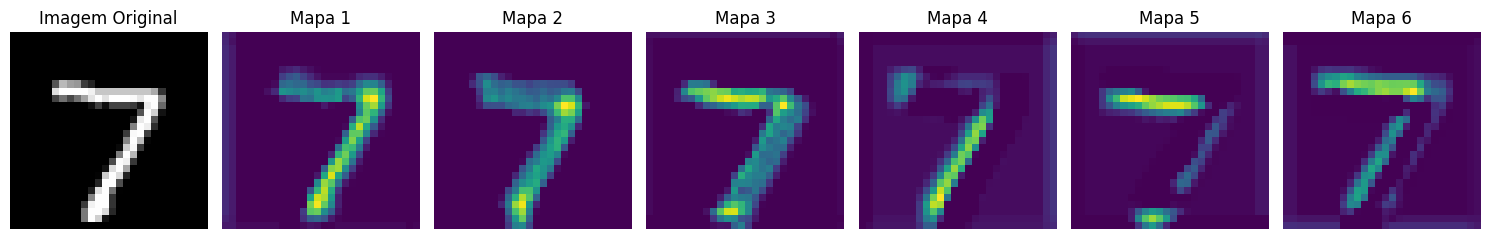

In [18]:
# Obter um lote de imagens de teste
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Selecionar a primeira imagem e adicionar a dimensão do batch
img = images[0].unsqueeze(0).to(device)

# Passar a imagem pela primeira camada convolucional (C1)
with torch.no_grad():
    # Aplicar a convolução C1 e em seguida a ativação ReLU:
    output_c1 = model.c1(img)
    output_c1_activated = F.relu(output_c1)

# O formato de saída será de 6 canais
feature_maps = output_c1_activated.squeeze(0).cpu().numpy()

fig, axes = plt.subplots(1, 7, figsize=(15, 3))

# Imagem Original
axes[0].imshow(img.squeeze().cpu().numpy(), cmap='gray')
axes[0].set_title('Imagem Original')
axes[0].axis('off')

# 6 Feature Maps da Camada C1
for i in range(6):
    axes[i+1].imshow(feature_maps[i], cmap='viridis')
    axes[i+1].set_title(f'Mapa {i+1}')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()